In [1]:
print("ok")

ok


In [2]:
# ==========================================================
# Imports
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

In [3]:
from pathlib import Path

for p in Path("/kaggle/input/notebooks").rglob("*"):
    print(p)

/kaggle/input/notebooks/shri7ul
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__results__.html
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/master_feature_engineered.parquet
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__notebook__.ipynb
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__results___files
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__output__.json
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/custom.css
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__results___files/__results___10_0.png
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__results___files/__results___5_0.png
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__results___files/__results___11_1.png
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__results___files/__results___8_1.png


In [4]:
# ==========================================================
# Load Feature Engineered Dataset
# ==========================================================

MASTER = Path(
    "/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/master_feature_engineered.parquet"
)

master = pd.read_parquet(MASTER)

print(master.shape)

master.head()

(35072, 122)


,response_id,session_id,learning_objective_id,learning_objective,transcript,student_text,tutor_text,background_text,is_correct,objective_frequency,...,log_unclear_count,log_digit_count,log_math_symbol_count,log_encouragement_score,log_instruction_score,log_student_uncertainty_score,background_heavy,many_questions,many_unclear,long_session
0,aaaavsh,bcaufvc,dqibnvd,Knowing the value of each digit in numbers wit...,"[BACKGROUND] [unclear]\n[TUTOR] Miss, I can't ...","Can you hear me? Hello? Yeah, I hear you. Can ...","Miss, I can't hear. Can you hear me? [unclear]...","[unclear] Good, very good. [unclear] And we wi...",1.0,1267,...,4.595120,5.926926,2.564949,3.433987,4.007333,0.693147,0,0,1,0
1,aaabhzi,eyutanf,eukmzxl,Adding and subtracting tens to a 2-digit number.,[TUTOR] Yay! Hello!\n[STUDENT] Hello.\n[TUTOR]...,Hello. Hello. I was one minute early. I'm one ...,Yay! Hello! Hello. Hello. [Speaker:Background]...,20. What 2-digit number can you make using the...,1.0,44,...,4.382027,6.198479,3.828641,3.891820,4.624973,2.484907,0,0,0,1
2,aaahpnz,juptkxd,fjbqcsv,Comparing and ordering fractions by finding a ...,[BACKGROUND] [unclear]\n[TUTOR] Is it me you a...,Hello. Hello. Yes. Good. How are you? Normal. ...,"Is it me you are looking for? Okay, so did you...","[unclear] Hello. Hello, Callum. Can you hear m...",0.0,211,...,4.532599,6.658011,4.406719,4.248495,4.158883,1.609438,0,0,1,1
3,aaajpom,ntwkcfj,acvbcev,Comparing fractions using reasoning.,[BACKGROUND] [unclear]\n[TUTOR] Hello?\n[STUDE...,"Hello, Tobias. Can you hear me? Okay, that's n...","Hello? Yes, I can hear you. Good. Why are you ...","[unclear] 1.45 meters. Excellent. Yes, good. G...",0.0,510,...,4.394449,6.603944,3.332205,4.672829,4.543295,2.564949,0,1,0,1
4,aaamwux,jqriibm,krfuudx,Counting in multiples.,[BACKGROUND] [unclear]\n[TUTOR] Hello.\n[STUDE...,"Hello. Good. Okay, how was this week for you? ...",Hello. Hello. Are you feeling tired today? Is ...,"[unclear] Hello. Hi, Caelum. How are you doing...",0.0,525,...,4.510860,6.066108,0.693147,3.737670,3.663562,1.609438,0,1,1,0


In [5]:
# ==========================================================
# Dataset Overview
# ==========================================================

TARGET = "is_correct"

print("="*60)

print("Rows :", len(master))
print("Columns :", len(master.columns))

print()

print(master[TARGET].value_counts(normalize=True))

print("="*60)

Rows : 35072
Columns : 122

is_correct
1.0    0.702469
0.0    0.297531
Name: proportion, dtype: float64


In [6]:
# ==========================================================
# Prepare Features
# ==========================================================

DROP_COLUMNS = [

    "response_id",
    "session_id",

    "learning_objective",
    "learning_objective_id",

    "transcript",
    "student_text",
    "tutor_text",
    "background_text",

    TARGET,
]

X = master.drop(columns=DROP_COLUMNS)

y = master[TARGET].astype(int)

print(X.shape)

(35072, 113)


In [7]:
# ==========================================================
# Encode Categoricals
# ==========================================================

categorical_cols = X.select_dtypes(include="object").columns.tolist()

print(categorical_cols)

for col in categorical_cols:
    X[col] = X[col].astype("category").cat.codes

['objective_family']


In [8]:
# ==========================================================
# LightGBM Baseline
# ==========================================================

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

oof_pred = np.zeros(len(X))

scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):

    print("="*60)
    print(f"Fold {fold}")
    print("="*60)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = LGBMClassifier(

        objective="binary",

        n_estimators=3000,

        learning_rate=0.03,

        num_leaves=31,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        n_jobs=-1,
    )

    model.fit(

        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        eval_metric="binary_logloss",

        callbacks=[],
    )

    pred = model.predict_proba(X_valid)[:,1]

    oof_pred[valid_idx] = pred

    loss = log_loss(y_valid, pred)

    scores.append(loss)

    print(f"Fold {fold} LogLoss : {loss:.6f}")

print()

print("="*60)

print("Fold LogLoss")

print(scores)

print()

print("Mean LogLoss :", np.mean(scores))

print("Std LogLoss  :", np.std(scores))

print("="*60)

Fold 1
[LightGBM] [Info] Number of positive: 19709, number of negative: 8348
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14676
[LightGBM] [Info] Number of data points in the train set: 28057, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.702463 -> initscore=0.859053
[LightGBM] [Info] Start training from score 0.859053
Fold 1 LogLoss : 0.566608
Fold 2
[LightGBM] [Info] Number of positive: 19709, number of negative: 8348
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023740 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14680
[LightGBM] [Info] Number of data points in the train set: 28057, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.702463 -> initscore=0.859053
[LightGBM] [Info] Start tra

In [9]:
# ==========================================================
# Overall OOF LogLoss
# ==========================================================

overall = log_loss(y, oof_pred)

print("="*60)

print(f"Overall OOF LogLoss : {overall:.6f}")

print("="*60)

Overall OOF LogLoss : 0.576354


In [10]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "feature": X.columns,

    "importance": model.feature_importances_

})

importance = importance.sort_values(

    "importance",

    ascending=False

)

display(importance.head(30))

,feature,importance
0,objective_frequency,3238
6,objective_avg_word_length,2772
4,objective_char_count,2662
100,encouragement_per_turn,1863
65,math_symbol_count,1812
61,question_ratio,1797
101,instruction_per_turn,1783
66,digit_ratio,1756
97,questions_per_turn,1722
53,background_turn_fraction,1669


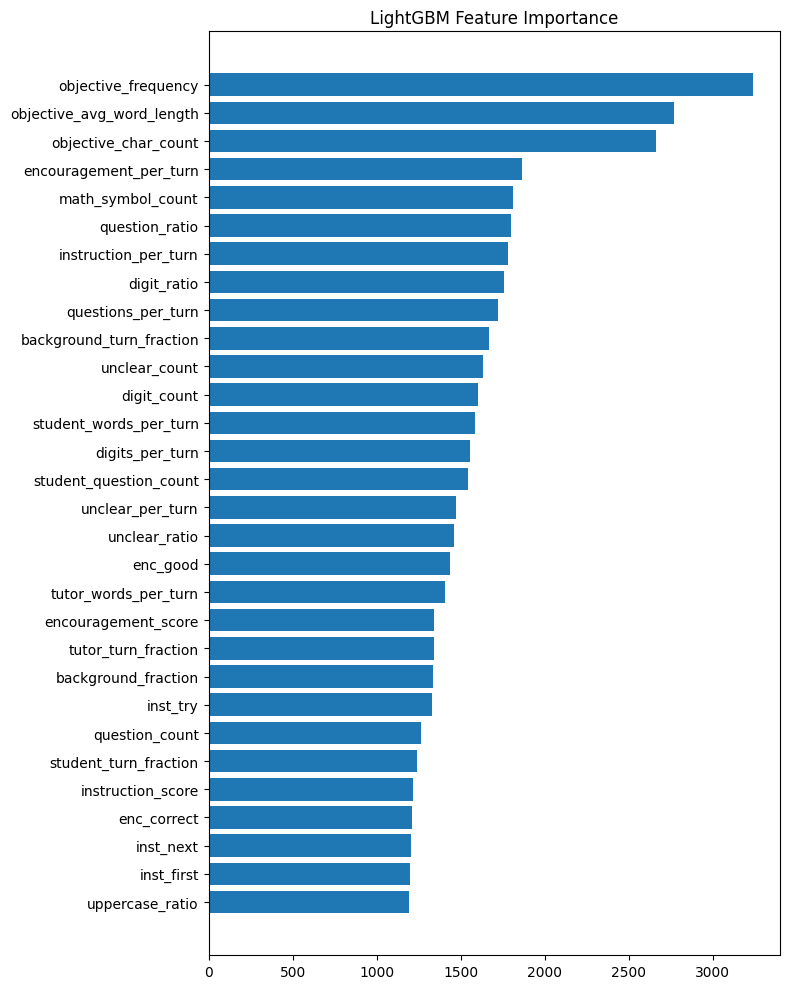

In [11]:
# ==========================================================
# Top 30 Features
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,10))

plt.barh(

    importance.head(30)["feature"][::-1],

    importance.head(30)["importance"][::-1]

)

plt.title("LightGBM Feature Importance")

plt.tight_layout()

plt.show()